# Cellular Learning Automata vs Apriori sul dataset mushroom

In [ ]:
import time
import itertools
import pandas as pd
import matplotlib.pyplot as plt

# Parte 1 - Cellular Learning Automata

Nella prima parte del notebook viene implementato il metodo proposto nel paper "**Frequent itemset mining using cellular learning automata**" di Sohrabi e Roshani. Rispetto ai tradizionali algoritmi di itemset mining come ad esempio Apriori, il vantaggio del metodo proposto è quello di poter essere eseguito in un minor tempo. L'implementazione cerca di seguire nella maniera più fedele possibile i passaggi mostrati nell'articolo. Inizialmente sono state definite le classi:


*   Item: rappresenta i singoli elementi. La classe presenta due attributi: name e support.
*   Transaction: rappresenta le righe del dataset. Ciascuna transazione è caratterizzata da un insieme di item e da un iteration number che indica quante volte quella transazione si ripete nel dataset.
* Cell: rappresenta la cella. Gli attributi sono name e un dizionario proximity_list che viene utilizzato per memorizzare i vicini.
* Neighbor: rappresenta un vicino in una cella. Gli attributi sono name, iteration_number, cioè il supporto e un dizionario proximity_list per memorizzare i vicini.





In [ ]:
class Item:
    def __init__(self, name, support):
        self.name = name
        self.support = support

class Transaction:
    def __init__(self, items, iteration_number):
        self.items = items
        self.iteration_number = iteration_number

class Cell:
    def __init__(self, name):
        self.name = name
        self.proximity_list = {}

class Neighbor:
    def __init__(self, name, iteration_number=0):
        self.name = name
        self.iteration_number = iteration_number
        self.proximity_list = {}

Nella sezione 3.1 dell’articolo viene descritta la prima fase, ovvero il mining degli itemset frequenti di dimensione 1. Questa operazione viene utilizzata nella seconda fase per il pruning e la compressione del dataset e per l’inizializzazione delle celle. La funzione utilizzata è:

* find_1_itemsets(dataset, minsup): Inizialmente, viene inizializzato un dizionario vuoto, item_support, utilizzato per memorizzare il supporto di ciascun item. Per ogni transazione presente nel dataset e per ogni item contenuto nella transazione, si verifica se l’item è già presente nel dizionario. L’operazione get(item_name, 0) + 1 consente di incrementare di uno il valore associato all’item ogni volta che questo viene incontrato; se l’item non è ancora presente, viene restituito il valore 0 e viene quindi inizializzato il relativo conteggio a 1.
Una volta analizzate tutte le transazioni del dataset, si individuano gli itemset frequenti scorrendo il dizionario item_support. Per ogni item, se il valore del supporto è maggiore o uguale a minsup, l’item viene considerato frequente e viene aggiunto alla lista frequent_itemsets attraverso la creazione di un nuovo oggetto Item, contenente il nome dell’item e il relativo supporto.
Infine, la lista degli itemset frequenti viene ordinata in ordine alfabetico sulla base del nome dell’item e restituita dalla funzione.


In [ ]:
def find_1_itemsets(dataset, minsup):
    item_support = {}
    for transaction in dataset:
        for item_name in transaction:
            item_support[item_name] = item_support.get(item_name, 0) + 1
    frequent_itemsets = []
    for item_name, support in item_support.items():
        if support >= minsup:
            frequent_itemsets.append(Item(item_name, support))
    frequent_itemsets_sorted = sorted(frequent_itemsets, key=lambda item: item.name)
    return frequent_itemsets_sorted

Nella sezione 3.2 dell’articolo viene descritta la seconda fase di pruning e compressione del dataset, che permette di velocizzare le operazioni successive. La funzione utilizzata è:
* prune_and_compress(dataset, frequent_itemset): inizialmente, utilizzando gli itemset frequenti di dimensione 1 precedentemente individuati, viene creato un set contenente i nomi degli item frequenti.
Successivamente, vengono analizzate tutte le transazioni del dataset. Per ciascuna transazione, si scorre ogni item e, se il suo nome è presente nel set degli item frequenti, questo viene aggiunto alla lista kept_items, contenente gli item da mantenere. In questo modo vengono eliminati dalle transazioni tutti gli item che non risultano frequenti.
Se la lista kept_items non è vuota, gli elementi vengono ordinati e utilizzati per creare una tupla, che viene impiegata come chiave del dizionario compressed_dataset. L'ordinamento permette di considerare equivalenti due transazioni contenenti gli stessi item ma presenti in un ordine differente, evitando quindi di memorizzarle come transazioni distinte.
Se una transazione con la stessa chiave è già presente nel dataset compresso, il relativo iteration_number viene incrementato di uno. Questo valore permette di tenere traccia del numero di transazioni originali che, dopo il pruning, risultano identiche. Se invece la transazione non è ancora presente, viene creato un nuovo oggetto Transaction con gli item mantenuti e iteration_number inizializzato a 1.
Infine, la funzione converte i valori del dizionario compressed_dataset in una lista di oggetti Transaction.


In [ ]:
def prune_and_compress_dataset(dataset, frequent_itemset):
    frequent_item_names = set()
    for item in frequent_itemset:
        frequent_item_names.add(item.name)
    compressed_dataset = {}
    for transaction in dataset:
        kept_items = []
        for item_name in transaction:
            if item_name in frequent_item_names:
                kept_items.append(item_name)
        if len(kept_items) > 0:
            key = tuple(sorted(kept_items))
            if key in compressed_dataset:
                compressed_dataset[key].iteration_number += 1
            else:
                compressed_dataset[key] = Transaction(kept_items, 1)
    compressed_transactions = list(compressed_dataset.values())
    return compressed_transactions

Nella sezione 3.3 dell’articolo viene descritta la parte fondamentale del metodo: la creazione delle celle e delle liste di prossimità.
Le funzioni utilizzate sono:
* run_cellular_automata(compressed_dataset, frequent_itemset): per ogni itemset frequente di dimensione 1 viene creata una cella, utilizzando il nome dell’item come identificativo della cella. Successivamente, vengono estratti i nomi degli item dagli oggetti Item e viene costruita la lista ordered_item_names. Per ogni transazione del dataset compresso vengono invece estratti gli item presenti e viene costruita una lista ordered_items, contenente solamente gli item della transazione che appartengono agli itemset frequenti e ordinati secondo l’ordine definito da ordered_item_names. A questo punto vengono analizzate tutte le celle. Se il nome della cella è presente nella transazione corrente, la cella viene considerata e viene costruita la lista remaining_items, che contiene tutti gli elementi presenti nella transazione ad eccezione dell’item associato alla cella.
* update_proximity_list(neighbor, remaining_items, iteration_number): prende in input la proximity list della cella, gli elementi rimanenti e l’iteration_number della transazione. La funzione update_proximity_list svolge due operazioni principali:
  1. La prima consiste nello scorrere tutti gli elementi presenti in remaining_items. Per ciascun elemento, se non è ancora presente nella proximity list della cella, viene creato un nuovo oggetto Neighbor. Successivamente, indipendentemente dal fatto che il Neighbor sia stato appena creato o fosse già presente, il suo iteration_number viene incrementato del valore iteration_number associato alla transazione corrente. In questo modo viene aggiornato il conteggio relativo alla presenza dell’elemento insieme alla cella.
  2. La seconda operazione consiste nel considerare, per ogni elemento analizzato, tutti gli elementi che lo seguono nella lista remaining_items. Per ciascuno di questi elementi viene verificato se è già presente nella proximity list del Neighbor associato all’elemento corrente. Se non è presente, viene creato un nuovo oggetto Neighbor; successivamente, il relativo iteration_number viene incrementato del valore iteration_number della transazione corrente. In questo modo vengono registrate anche le relazioni di prossimità tra gli elementi secondo il loro ordine all’interno della transazione.
Infine, una volta analizzate tutte le transazioni, la funzione run_cellular_automata restituisce la lista delle celle, ciascuna contenente le informazioni relative agli elementi con cui è stata osservata e alle rispettive relazioni di prossimità.


In [ ]:
def update_proximity_list(neighbor, remaining_items, iteration_number):
    for i in range(len(remaining_items)):
        current_item_name = remaining_items[i]
        if current_item_name not in neighbor:
            neighbor[current_item_name] = Neighbor(current_item_name)
        stored_neighbor = neighbor[current_item_name]
        stored_neighbor.iteration_number += iteration_number
        subsequent_items = remaining_items[i + 1:]
        for subsequent_item_name in subsequent_items:
            if subsequent_item_name not in stored_neighbor.proximity_list:
                stored_neighbor.proximity_list[subsequent_item_name] = Neighbor(subsequent_item_name)
            stored_pair_neighbor = stored_neighbor.proximity_list[subsequent_item_name]
            stored_pair_neighbor.iteration_number += iteration_number

def run_cellular_automata(compressed_dataset, frequent_itemset):
    cells = []
    for item in frequent_itemset:
        cells.append(Cell(item.name))
    ordered_item_names = []
    for item in frequent_itemset:
        ordered_item_names.append(item.name)
    for transaction in compressed_dataset:
        transaction_itemset = set(transaction.items)
        ordered_items = []
        for name in ordered_item_names:
            if name in transaction_itemset:
                ordered_items.append(name)
        for cell in cells:
            if cell.name in ordered_items:
                remaining_items = []
                for item_name in ordered_items:
                    if item_name != cell.name:
                        remaining_items.append(item_name)
                update_proximity_list(cell.proximity_list, remaining_items, transaction.iteration_number)
    return cells

Nella sezione 3.4 dell’articolo viene descritta la fase di pruning e scanning delle proximity list. Le funzioni utilizzate sono:
* prune_cells(cells, minsup): per ogni cella applica la funzione prune_proximity_list alla relativa proximity list.
* prune_proximity_list(neighbor, minsup): mantiene solamente i Neighbor il cui iteration_number è >= a minsup. Per ogni Neighbor che supera questa soglia, la funzione viene richiamata ricorsivamente sulla sua proximity list, applicando quindi lo stesso criterio di pruning anche ai livelli successivi. In questo modo vengono mantenuti solamente i Neighbor che soddisfano il supporto minimo richiesto e, per ciascuno di essi, vengono ulteriormente potate le relative liste di prossimità.
* scan_cells(cells, max_len): rappresenta il punto di partenza per l'estrazione degli itemset. Per ogni cella viene innanzitutto aggiunto l'item associato alla cella come 1-itemset. Successivamente, viene chiamata la funzione collect_itemsets, passando il nome della cella come prefisso dell'itemset corrente.
* collect_itemsets(neighbor, prefix_item, max_len): scorre i Neighbor presenti nella proximity list e, per ciascuno di essi, costruisce un nuovo itemset aggiungendo il nome del Neighbor al prefisso corrente. Se la lunghezza dell'itemset ottenuto è inferiore a max_len, la funzione viene richiamata ricorsivamente sulla proximity list del Neighbor appena considerato. In questo modo è possibile costruire itemset di dimensione crescente, seguendo le relazioni presenti nelle liste di prossimità, fino a raggiungere la lunghezza massima specificata.
* remove_duplicate(itemsets): elimina gli itemset duplicati. Per ogni itemset, gli elementi vengono ordinati e trasformati in una tupla, che viene inserita in un set. Questa operazione permette di considerare equivalenti itemset contenenti gli stessi elementi ma in ordine differente. Il set risultante viene infine convertito in una lista ordinata e restituito.
* cla_mining(dataset, minsup, max_len): coordina tutte le fasi precedenti, individua gli 1-itemset frequenti, esegue il pruning e la compressione del dataset, costruisce le celle e le relative liste di prossimità, applica il pruning delle proximity list, effettua lo scanning delle celle per generare gli itemset e, infine, elimina gli eventuali duplicati.


In [ ]:
def prune_proximity_list(neighbor, minsup):
    kept_proximity_lists = {}
    for name, neighbor in neighbor.items():
        if neighbor.iteration_number >= minsup:
            neighbor.proximity_list = prune_proximity_list(neighbor.proximity_list, minsup)
            kept_proximity_lists[name] = neighbor
    return kept_proximity_lists

def prune_cells(cells, minsup):
    for cell in cells:
        cell.proximity_list = prune_proximity_list(cell.proximity_list, minsup)

def collect_itemsets(neighbor, prefix_item, max_len):
    itemsets = []
    for neighbor in neighbor.values():
        current_itemset = prefix_item + [neighbor.name]
        itemsets.append(tuple(current_itemset))
        if len(current_itemset) < max_len:
            itemsets.extend(collect_itemsets(neighbor.proximity_list, current_itemset, max_len))
    return itemsets

def scan_cells(cells, max_len=3):
    all_itemsets = []
    for cell in cells:
        all_itemsets.append((cell.name,))
        all_itemsets.extend(collect_itemsets(cell.proximity_list, [cell.name], max_len))
    return all_itemsets

def remove_duplicate(itemsets):
    unique_itemsets = set()
    for itemset in itemsets:
        unique_itemsets.add(tuple(sorted(itemset)))
    return sorted(unique_itemsets)

def cla_mining(dataset, minsup, max_len=3):
    frequent_1_itemsets = find_1_itemsets(dataset, minsup)
    compressed_dataset = prune_and_compress_dataset(dataset, frequent_1_itemsets)
    cells = run_cellular_automata(compressed_dataset, frequent_1_itemsets)
    prune_cells(cells, minsup)
    return remove_duplicate(scan_cells(cells, max_len))

# Parte 2 - Apriori

Nella seconda parte del notebook viene implementato l’algoritmo Apriori con l’obiettivo di confrontare il tempo di esecuzione di questo algoritmo con quello del metodo proposto nell’articolo. L’algoritmo Apriori è caratterizzato da due operazioni principali. La prima, in maniera analoga a quanto fatto in precedenza, consiste nell’individuazione degli itemset frequenti di dimensione 1. La funzione utilizzata è:
 * find_1_itemsets_apriori(dataset, minsup): inizialmente viene creato un dizionario per memorizzare il supporto di ciascun item. Successivamente, per ogni transazione del dataset e per ogni item presente nella transazione, viene incrementato di uno il supporto dell’item ogni volta che questo viene incontrato. Una volta analizzate tutte le transazioni, viene scansionato il dizionario e vengono aggiunti alla lista frequent_1_itemsets solamente gli item il cui supporto è maggiore o uguale a minsup. Ogni item frequente viene rappresentato come una tupla contenente un solo elemento. Infine, la funzione ordina e restituisce la lista degli itemset frequenti di dimensione 1.


In [ ]:
def find_1_itemsets_apriori(dataset, minsup):
    item_support = {}
    for transaction in dataset:
        for item_name in transaction:
            item_support[item_name] = item_support.get(item_name, 0) + 1
    frequent_1_itemsets = []
    for item_name, support in item_support.items():
        if support >= minsup:
            frequent_1_itemsets.append((item_name,))
    frequent_1_itemsets_sorted = sorted(frequent_1_itemsets)
    return frequent_1_itemsets_sorted

Nella seconda parte vengono implementate le seguenti funzioni:

* generate_candidate(frequent_itemsets, target_length): ha il compito di generare gli itemset candidati di una determinata dimensione a partire dagli itemset frequenti della dimensione precedente. Inizialmente, gli itemset frequenti vengono ordinati. Successivamente, viene calcolato prefix_length, che indica il numero di elementi iniziali che due itemset devono avere in comune per poter essere uniti. La funzione confronta quindi ogni coppia di itemset distinti e verifica se i rispettivi prefissi coincidono. Se coincidono, i due itemset vengono uniti creando un nuovo insieme contenente tutti gli elementi dei due itemset. Gli elementi ottenuti vengono ordinati e trasformati in una tupla. Se la lunghezza dell’itemset risultante è uguale a target_length, questo viene aggiunto all’insieme degli itemset candidati. L’utilizzo di un set permette di evitare eventuali duplicati. Infine, gli itemset candidati vengono ordinati e la lista risultante viene restituita dalla funzione.
* verify_antimonotonicity(candidate_itemset, previous_itemsets): questa funzione verifica la proprietà di antimonotonicità utilizzata dall'algoritmo Apriori per effettuare il pruning degli itemset candidati. In particolare, vengono considerati tutti i sottoinsiemi del candidato ottenuti eliminando un singolo elemento. Se almeno uno di questi sottoinsiemi non è presente nell'insieme degli itemset frequenti della dimensione precedente, la funzione restituisce False, indicando che il candidato non può essere considerato frequente e deve quindi essere scartato. Se invece tutti i sottoinsiemi risultano presenti negli itemset precedenti, la funzione restituisce True e il candidato supera questo controllo.
* count_candidates_support(dataset, candidate_itemsets): questa funzione inizializza un dizionario utilizzando come chiavi tutti gli itemset candidati e impostando a zero il relativo supporto. Successivamente, per ogni transazione del dataset, la transazione viene convertita in un set. Per ogni itemset candidato viene quindi verificato se tutti i suoi elementi sono presenti nella transazione, utilizzando il controllo issubset(). Se il candidato è contenuto nella transazione, il suo supporto viene incrementato di uno. Al termine della scansione del dataset, la funzione restituisce il dizionario contenente, per ogni itemset candidato, il relativo supporto.
* filter_frequent_itemsets(candidate_support, minsup): questa funzione seleziona gli itemset frequenti a partire dal dizionario contenente il supporto degli itemset candidati. In particolare, vengono aggiunti alla lista frequent_itemsets tutti gli itemset il cui supporto è maggiore o uguale a minsup. Infine, gli itemset frequenti vengono ordinati e restituiti dalla funzione.
* apriori_mining(dataset, minsup, max_len): questa funzione rappresenta l'intera esecuzione dell'algoritmo Apriori. Inizialmente vengono estratti gli itemset frequenti di dimensione 1, che vengono utilizzati come punto di partenza per la generazione degli itemset di dimensione successiva. Successivamente, per ogni dimensione fino a max_len, vengono generati gli itemset candidati a partire dagli itemset frequenti della dimensione precedente. Sui candidati viene applicata la proprietà di antimonotonicità, in modo da mantenere solamente quelli i cui sottoinsiemi di dimensione precedente risultano frequenti. Una volta ottenuto l'insieme dei candidati da considerare, viene calcolato il loro supporto attraverso una scansione del dataset e vengono mantenuti solamente gli itemset il cui supporto è maggiore o uguale a minsup.
Gli itemset frequenti ottenuti vengono quindi utilizzati come base per la generazione dei candidati della dimensione successiva. Questo procedimento viene ripetuto fino al raggiungimento della dimensione massima desiderata oppure fino a quando non vengono più trovati itemset frequenti. Infine, tutti gli itemset frequenti individuati ai diversi livelli vengono raccolti in un'unica lista e restituiti dalla funzione.





In [ ]:
def generate_candidate(frequent_itemsets, target_length):
    frequent_itemsets_sorted = sorted(frequent_itemsets)
    candidate_itemsets = set()
    prefix_length = target_length - 2
    for i in range(len(frequent_itemsets_sorted)):
        for j in range(i + 1, len(frequent_itemsets_sorted)):
            first_itemset = frequent_itemsets_sorted[i]
            second_itemset = frequent_itemsets_sorted[j]
            if first_itemset[:prefix_length] == second_itemset[:prefix_length]:
                merged_items = tuple(sorted(set(first_itemset) | set(second_itemset)))
                if len(merged_items) == target_length:
                    candidate_itemsets.add(merged_items)
    candidate_itemsets_sorted = sorted(candidate_itemsets)
    return candidate_itemsets_sorted

def verify_antimonotonicity(candidate_itemset, previous_itemsets):
    previous_itemsets_set = set(previous_itemsets)
    for position in range(len(candidate_itemset)):
        subset_itemset = candidate_itemset[:position] + candidate_itemset[position + 1:]
        if subset_itemset not in previous_itemsets_set:
            return False
    return True

def count_candidates_support(dataset, candidate_itemsets):
    candidate_support = {}
    for candidate_itemset in candidate_itemsets:
        candidate_support[candidate_itemset] = 0
    for transaction in dataset:
        transaction_set = set(transaction)
        for candidate_itemset in candidate_itemsets:
            if set(candidate_itemset).issubset(transaction_set):
                candidate_support[candidate_itemset] += 1
    return candidate_support

def filter_frequent_itemsets(candidate_support, minsup):
    frequent_itemsets = []
    for candidate_itemset, support in candidate_support.items():
        if support >= minsup:
            frequent_itemsets.append(candidate_itemset)
    frequent_itemsets_sorted = sorted(frequent_itemsets)
    return frequent_itemsets_sorted

def apriori_mining(dataset, minsup, max_len=3):
    itemsets_by_level = []
    frequent_1_itemsets = find_1_itemsets_apriori(dataset, minsup)
    itemsets_by_level.append(frequent_1_itemsets)
    previous_itemsets = frequent_1_itemsets
    for target_length in range(2, max_len + 1):
        candidate_itemsets = generate_candidate(previous_itemsets, target_length)
        kept_itemsets = []
        for candidate_itemset in candidate_itemsets:
            if verify_antimonotonicity(candidate_itemset, previous_itemsets):
                kept_itemsets.append(candidate_itemset)
        candidate_support_counts = count_candidates_support(dataset, kept_itemsets)
        current_itemsets = filter_frequent_itemsets(candidate_support_counts, minsup)
        itemsets_by_level.append(current_itemsets)
        previous_itemsets = current_itemsets
        if len(current_itemsets) == 0:
            break
    all_frequent_itemsets = []
    for level_itemsets in itemsets_by_level:
        for itemset in level_itemsets:
            all_frequent_itemsets.append(itemset)
    return all_frequent_itemsets

# Parte 3 - Confronto dei tempi di esecuzione

Il confronto è stato svolto utilizzando il dataset Mushroom, presente anche nella sezione "Experimental results" dell’articolo. Poiché nel dataset i valori degli attributi sono rappresentati tramite lettere che possono ripetersi per attributi differenti, è necessario distinguere gli item associandoli all’attributo di riferimento. A questo scopo viene definita la lista ATTRIBUTE_NAMES, contenente i nomi degli attributi presenti nel dataset. La funzione load_dataset legge il file riga per riga, ignora eventuali righe vuote e divide ciascuna riga nei relativi valori utilizzando la virgola come separatore. Successivamente, per ogni valore viene creato un item concatenando il nome dell’attributo e il relativo valore, ottenendo una rappresentazione del tipo attributo=valore. In questo modo, valori uguali appartenenti ad attributi differenti vengono considerati come item distinti. La prima colonna del dataset, corrispondente alla classe, viene esclusa dalla costruzione delle transazioni. Le transazioni così ottenute vengono inserite nella lista dataset.


In [ ]:
ATTRIBUTE_NAMES = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat",
]

def load_dataset(file_path):
    dataset = []
    with open(file_path, "r") as file:
        for line in file:
            line = line.strip()
            if not line:
                continue
            values = line.split(",")
            transaction = [attribute + "=" + value for attribute, value in zip(ATTRIBUTE_NAMES[1:], values[1:])]
            dataset.append(transaction)
    return dataset

dataset_path = "/content/agaricus-lepiota.data"
dataset = load_dataset(dataset_path)

In questa parte vengono definite le funzioni utilizzate per confrontare le prestazioni dei due algoritmi. Le funzioni utilizzate sono:

* measure_execution_time(mining_function, dataset, minsup, max_len): questa funzione misura il tempo di esecuzione dell'algoritmo passato come parametro. Prima dell'esecuzione viene registrato il tempo iniziale tramite time.perf_counter(), mentre al termine dell'esecuzione viene registrato il tempo finale. La differenza tra i due valori rappresenta il tempo impiegato dall'algoritmo. La funzione restituisce sia il tempo di esecuzione sia la lista degli itemset individuati, quest'ultima utile per verificare successivamente il numero di itemset trovati.
* run_benchmark(dataset, minsup_fractions, max_len): questa funzione esegue il confronto tra CLA e Apriori per i diversi valori di minsup considerati. Inizialmente viene calcolato il numero di transazioni presenti nel dataset. Per ogni valore di minsup_fraction, espresso come frazione del numero totale di transazioni, viene calcolato il corrispondente valore assoluto di minsup. Successivamente, vengono eseguiti entrambi gli algoritmi utilizzando lo stesso dataset, lo stesso valore di minsup e lo stesso max_len, e vengono memorizzati i rispettivi tempi di esecuzione. Per ogni valore di minsup vengono inoltre stampati i tempi ottenuti e il numero di itemset individuati dai due algoritmi. Infine, la funzione restituisce le liste contenenti i tempi di esecuzione di CLA e Apriori.
* plot_benchmark_results(minsup_fractions, cla_times, apriori_times): questa funzione visualizza graficamente i risultati del benchmark. Sull'asse delle ascisse viene riportato il valore di minsup, mentre sull'asse delle ordinate viene riportato il tempo di esecuzione in secondi. Vengono quindi rappresentate due curve, una relativa a CLA e una relativa ad Apriori, in modo da confrontarne visivamente le prestazioni al variare del minsup.



minsup = 0.2 CLA: 1.5333 s (itemset trovati: 1594 ) Apriori: 6.6553 s (itemset trovati: 1594 )

Itemset uguali: True
Solo CLA: 0
Solo Apriori: 0

minsup = 0.4 CLA: 0.0691 s (itemset trovati: 256 ) Apriori: 0.846 s (itemset trovati: 256 )

Itemset uguali: True
Solo CLA: 0
Solo Apriori: 0

minsup = 0.6 CLA: 0.0372 s (itemset trovati: 43 ) Apriori: 0.1561 s (itemset trovati: 43 )

Itemset uguali: True
Solo CLA: 0
Solo Apriori: 0

minsup = 0.8 CLA: 0.0361 s (itemset trovati: 21 ) Apriori: 0.0929 s (itemset trovati: 21 )

Itemset uguali: True
Solo CLA: 0
Solo Apriori: 0

minsup = 1 CLA: 0.0308 s (itemset trovati: 1 ) Apriori: 0.0303 s (itemset trovati: 1 )

Itemset uguali: True
Solo CLA: 0
Solo Apriori: 0


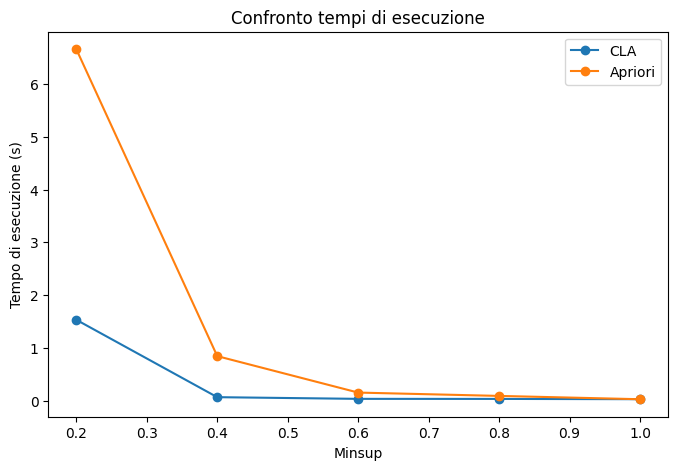

In [ ]:
def measure_execution_time(mining_function, dataset, minsup, max_len):
    start_time = time.perf_counter()
    itemsets_found = mining_function(dataset, minsup, max_len)
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    return elapsed_time, itemsets_found

def run_benchmark(dataset, minsup_fractions, max_len=3):
    number_of_transactions = len(dataset)
    cla_times = []
    apriori_times = []
    for minsup_fraction in minsup_fractions:
        minsup_absolute = minsup_fraction * number_of_transactions
        cla_time, cla_itemsets = measure_execution_time(cla_mining, dataset, minsup_absolute, max_len)
        cla_times.append(cla_time)
        apriori_time, apriori_itemsets = measure_execution_time(apriori_mining, dataset, minsup_absolute, max_len)
        apriori_times.append(apriori_time)
        print("\nminsup =", minsup_fraction, "CLA:", round(cla_time, 4), "s (itemset trovati:", len(cla_itemsets), ")",
              "Apriori:", round(apriori_time, 4), "s (itemset trovati:", len(apriori_itemsets),")\n")
        cla_set = set(cla_itemsets)
        apriori_set = set(apriori_itemsets)
        print("Itemset uguali:", cla_set == apriori_set)
        print("Solo CLA:", len(cla_set - apriori_set))
        print("Solo Apriori:", len(apriori_set - cla_set))
    return cla_times, apriori_times

def plot_benchmark_results(minsup_fractions, cla_times, apriori_times):
    plt.figure(figsize=(8, 5))
    plt.plot(minsup_fractions, cla_times, marker="o", label="CLA")
    plt.plot(minsup_fractions, apriori_times, marker="o", label="Apriori")
    plt.xlabel("Minsup")
    plt.ylabel("Tempo di esecuzione (s)")
    plt.title("Confronto tempi di esecuzione")
    plt.legend()
    plt.show()

minsup_fractions = [0.2, 0.4, 0.6, 0.8, 1]
cla_times, apriori_times = run_benchmark(dataset, minsup_fractions)
plot_benchmark_results(minsup_fractions, cla_times, apriori_times)